# Regressão usando PyCaret

## Instalação e configuração da biblioteca

In [ ]:
!pip install pycaret

In [ ]:
import numpy as np
from pycaret.utils import enable_colab
enable_colab()

Colab mode enabled.


## Base de dados

In [ ]:
from pycaret.datasets import get_data
todas_bases = get_data('index')

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,None,None,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,None,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,None,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,None,683,10,N
6,credit,Multivariate,Classification (Binary),default,None,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,None,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,None,10000,14,N
9,employee,Multivariate,Classification (Binary),left,None,14999,10,N


In [ ]:
dataset = get_data('automobile')

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [ ]:
type(dataset)

pandas.core.frame.DataFrame

In [ ]:
dataset.shape

(202, 26)

In [ ]:
base_treinamento = dataset.sample(frac=0.9, random_state=1)
base_treinamento.shape

(182, 26)

In [ ]:
base_treinamento.index

Int64Index([196,  95, 173, 123,  38,  94,  78,  58,  29,   4,
            ...
             22,  61,  63,   7, 198, 141,  86,  96,  68,  50],
           dtype='int64', length=182)

In [ ]:
base_teste = dataset.drop(base_treinamento.index)
base_teste.shape

(20, 26)

In [ ]:
base_teste.index

Int64Index([ 20,  25,  37,  71,  72,  79, 101, 129, 133, 134, 137, 139, 140,
            142, 144, 146, 156, 157, 178, 192],
           dtype='int64')

## Configuração do ambiente PyCaret

In [ ]:
from pycaret.regression import setup
experimento = setup(data = base_treinamento, target = 'price', session_id=1)

,Description,Value
0,session_id,1
1,Target,price
2,Original Data,"(182, 26)"
3,Missing Values,True
4,Numeric Features,10
5,Categorical Features,15
6,Ordinal Features,False
7,High Cardinality Features,False
8,High Cardinality Method,None
9,Transformed Train Set,"(127, 160)"


## Treinamento de vários modelos com validação cruzada

- Validação cruzada: https://www.youtube.com/watch?v=RczbeFs_WbQ

In [ ]:
from pycaret.regression import compare_models
modelos = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,1719.3674,6.044044e+06,2321.9999,0.9052,0.1487,0.1232,1.635
rf,Random Forest Regressor,1819.9370,7.068613e+06,2523.1744,0.8856,0.1615,0.1297,0.498
gbr,Gradient Boosting Regressor,1736.7991,6.657393e+06,2469.7238,0.8837,0.1503,0.1206,0.080
llar,Lasso Least Angle Regression,1908.3063,7.866307e+06,2649.9789,0.8718,0.1956,0.1440,0.304
et,Extra Trees Regressor,1887.1963,7.317971e+06,2598.4582,0.8717,0.1738,0.1417,0.456
omp,Orthogonal Matching Pursuit,1972.5666,7.109002e+06,2608.1305,0.8700,0.2061,0.1475,0.016
xgboost,Extreme Gradient Boosting,1957.0482,7.729103e+06,2705.7916,0.8595,0.1640,0.1321,0.727
ada,AdaBoost Regressor,2115.7006,7.845012e+06,2719.4178,0.8567,0.1939,0.1692,0.099
ridge,Ridge Regression,2409.8178,9.462936e+06,3023.7558,0.8233,0.2486,0.1953,0.017
lightgbm,Light Gradient Boosting Machine,2334.8511,1.145411e+07,3238.6670,0.8160,0.2033,0.1651,0.034


## Tuning dos modelos

In [ ]:
from pycaret.regression import create_model
dt = create_model('dt')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,1073.1538,1.782165e+06,1334.9777,0.9344,0.1201,0.1002
1,3352.6154,1.996031e+07,4467.6961,0.5666,0.2598,0.2232
2,2561.6923,1.324685e+07,3639.6225,0.7550,0.2462,0.1891
3,2739.7692,1.635910e+07,4044.6387,0.8791,0.2174,0.1423
4,1611.0769,5.144827e+06,2268.2211,0.9203,0.2065,0.1322
5,2846.7692,1.765878e+07,4202.2351,0.8777,0.2299,0.1852
6,2220.0769,8.031112e+06,2833.9217,0.8278,0.2005,0.1735
7,1972.8333,6.509762e+06,2551.4235,0.9103,0.1473,0.1359
8,2664.7500,1.554367e+07,3942.5459,0.5056,0.2361,0.2081
9,2344.6667,1.527470e+07,3908.2864,0.5977,0.2830,0.1503


In [ ]:
dt

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=None,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=1, splitter='best')

In [ ]:
from pycaret.regression import tune_model
dt_tuning = tune_model(dt)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,1161.2348,2.659603e+06,1630.8290,0.9021,0.1329,0.1029
1,1810.3362,5.121416e+06,2263.0546,0.8888,0.1737,0.1442
2,3107.0055,1.581887e+07,3977.2940,0.7074,0.2672,0.2177
3,3064.5058,1.795325e+07,4237.1277,0.8673,0.2461,0.1679
4,1601.3590,4.335817e+06,2082.2624,0.9329,0.1768,0.1291
5,2129.1725,8.893778e+06,2982.2438,0.9384,0.1580,0.1360
6,1760.5393,6.768613e+06,2601.6558,0.8549,0.2158,0.1547
7,1544.6840,3.887258e+06,1971.6130,0.9465,0.1370,0.1109
8,2444.7074,1.168472e+07,3418.2920,0.6284,0.2053,0.1773
9,2547.5296,1.076235e+07,3280.6021,0.7166,0.2042,0.1620


In [ ]:
dt_tuning

DecisionTreeRegressor(ccp_alpha=0.0, criterion='friedman_mse', max_depth=15,
                      max_features=1.0, max_leaf_nodes=None,
                      min_impurity_decrease=0.2, min_impurity_split=None,
                      min_samples_leaf=6, min_samples_split=7,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=1, splitter='best')

## Gráficos

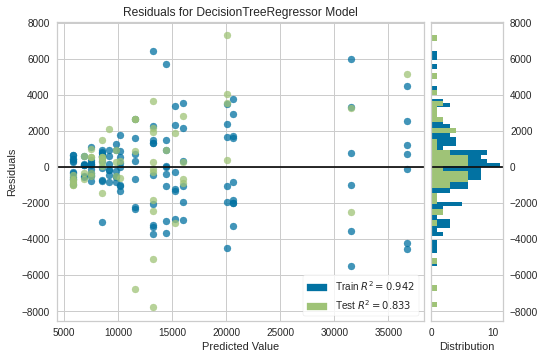

In [ ]:
from pycaret.regression import plot_model
plot_model(dt_tuning)

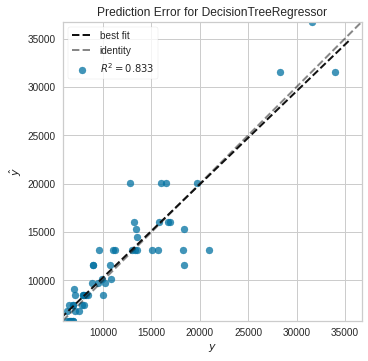

In [ ]:
plot_model(dt_tuning, plot = 'error')

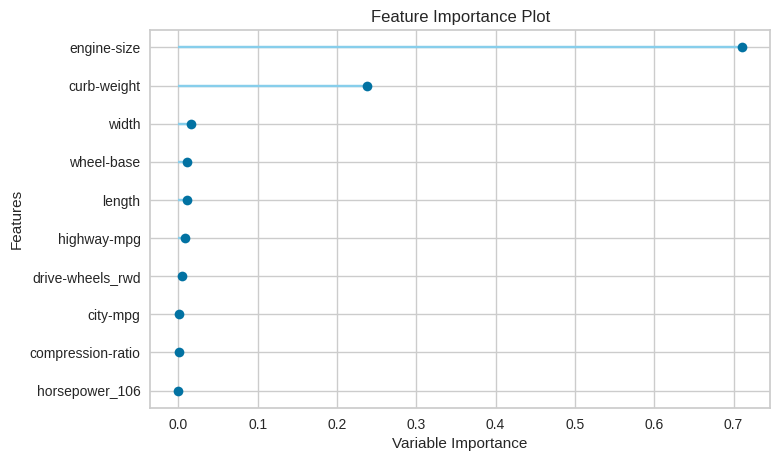

In [ ]:
plot_model(dt_tuning, 'feature')

In [ ]:
from pycaret.regression import evaluate_model
evaluate_model(dt_tuning)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

## Previsões com o modelo

In [ ]:
from pycaret.regression import predict_model
predict_model(dt_tuning);

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Decision Tree Regressor,1709.7772,6.280738e+06,2506.1401,0.8332,0.1724,0.1345


In [ ]:
from pycaret.regression import finalize_model
dt_final = finalize_model(dt_tuning)
print(dt_final)

DecisionTreeRegressor(ccp_alpha=0.0, criterion='friedman_mse', max_depth=15,
                      max_features=1.0, max_leaf_nodes=None,
                      min_impurity_decrease=0.2, min_impurity_split=None,
                      min_samples_leaf=6, min_samples_split=7,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=1, splitter='best')


In [ ]:
from pycaret.regression import save_model
save_model(dt_final,'dt')

Transformation Pipeline and Model Succesfully Saved


(Pipeline(memory=None,
          steps=[('dtypes',
                  DataTypes_Auto_infer(categorical_features=[],
                                       display_types=True, features_todrop=[],
                                       id_columns=[], ml_usecase='regression',
                                       numerical_features=[], target='price',
                                       time_features=[])),
                 ('imputer',
                  Simple_Imputer(categorical_strategy='not_available',
                                 fill_value_categorical=None,
                                 fill_value_numerical=None,
                                 numeric_strategy='...
                 ('dfs', 'passthrough'), ('pca', 'passthrough'),
                 ['trained_model',
                  DecisionTreeRegressor(ccp_alpha=0.0, criterion='friedman_mse',
                                        max_depth=15, max_features=1.0,
                                        max_leaf_nodes=None,

In [ ]:
from pycaret.regression import load_model
dt_carregado = load_model('/content/dt')

Transformation Pipeline and Model Successfully Loaded


In [ ]:
previsoes = predict_model(dt_carregado, data=base_teste)
previsoes

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,Label
20,1,118.0,dodge,gas,std,two,hatchback,fwd,front,93.7,157.3,63.8,50.8,1876,ohc,four,90,2bbl,2.97,3.23,9.41,68,5500,37,41,5572,5837.142857
25,1,148.0,dodge,gas,std,four,sedan,fwd,front,93.7,157.3,63.8,50.6,1989,ohc,four,90,2bbl,2.97,3.23,9.40,68,5500,31,38,7609,6652.600000
37,0,106.0,honda,gas,std,two,hatchback,fwd,front,96.5,167.5,65.2,53.3,2289,ohc,four,110,1bbl,3.15,3.58,9.00,86,5800,27,33,9095,8113.125000
71,1,NaN,mercedes-benz,gas,std,two,hardtop,rwd,front,112.0,199.2,72.0,55.4,3715,ohcv,eight,304,mpfi,3.8,3.35,8.00,184,4500,14,16,45400,35883.888889
72,1,NaN,mercury,gas,turbo,two,hatchback,rwd,front,102.7,178.4,68.0,54.8,2910,ohc,four,140,mpfi,3.78,3.12,8.00,175,5000,19,24,16503,18463.166667
79,3,NaN,mitsubishi,gas,turbo,two,hatchback,fwd,front,95.9,173.2,66.3,50.2,2833,ohc,four,156,spdi,3.58,3.86,7.00,145,5000,19,24,12629,12485.333333
101,3,194.0,nissan,gas,std,two,hatchback,rwd,front,91.3,170.7,67.9,49.7,3071,ohcv,six,181,mpfi,3.43,3.27,9.00,160,5200,19,25,17199,19024.625000
129,2,104.0,saab,gas,std,four,sedan,fwd,front,99.1,186.6,66.5,56.1,2695,ohc,four,121,mpfi,3.54,3.07,9.30,110,5250,21,28,12170,14573.545455
133,2,104.0,saab,gas,turbo,four,sedan,fwd,front,99.1,186.6,66.5,56.1,2847,dohc,four,121,mpfi,3.54,3.07,9.00,160,5500,19,26,18620,14573.545455
134,2,83.0,subaru,gas,std,two,hatchback,fwd,front,93.7,156.9,63.4,53.7,2050,ohcf,four,97,2bbl,3.62,2.36,9.00,69,4900,31,36,5118,7151.333333


In [ ]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(previsoes['price'], previsoes['Label'])

2098.2132539682543